In [ ]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name
)

In [2]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC=0.0, t_1=-1, x=[]):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    # Chosen occupancies for net spin == 0
    for label_i in subs:
        if label_i == "A":
            n_px_up = x[1]
            n_px_down = x[2]
            n_py_up = x[3]
            n_py_down = x[4]
            n_pz_up = x[5]
            n_pz_down = x[6]
        elif label_i == "B":
            n_px_up = x[7]
            n_px_down = x[8]
            n_py_up = x[9]
            n_py_down = x[10]
            n_pz_up = x[11]
            n_pz_down = x[12]
        else:
            n_px_up = x[13]
            n_px_down = x[14]
            n_py_up = x[15]
            n_py_down = x[16]
            n_pz_up = x[17]
            n_pz_down = x[18]
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["onsite_energy"][label_i]["E_s"] = -5
        parser["interaction"][label_i]["U_p"] = x[0]
        parser["interaction"][label_i]["n_px_up"] = n_px_up
        parser["interaction"][label_i]["n_px_down"] = n_px_down
        parser["interaction"][label_i]["n_py_up"] = n_py_up
        parser["interaction"][label_i]["n_py_down"] = n_py_down
        parser["interaction"][label_i]["n_pz_up"] = n_pz_up
        parser["interaction"][label_i]["n_pz_down"] = n_pz_down
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.01 * np.abs(t_1)
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1/2
            except:
                pass
        # print(parser)   

In [3]:
cases = {
    0: [
            0,
            0., 0, 0., 0, 0, 0,
            0.0, 0, 0.0, 0, 0, 0,
            0., 0, 0., 0.0, 0, 0,
    ], # NOTE: no interaction -> metal
    1:[
            3,
            0., 0, 0., 0, 1, 0,
            0.0, 0, 0.0, 0, 1, 0,
            0., 0, 0., 0.0, 0, 1,
    ], # NOTE: A & B up C down -> metal (single)
    2: [
            3,
            0., 0, 0., 0, 0, 1,
            0.0, 0, 0.0, 0, 1, 0,
            0., 0, 0., 0.0, 0, 1,
     ] # NOTE: A & C down, B up -> TI (single)

}


Running case for: U/t = -0.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


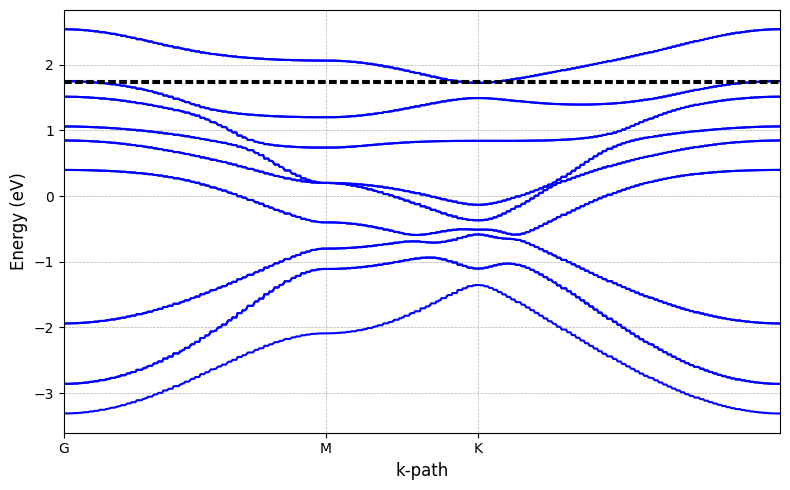


Running case for: U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


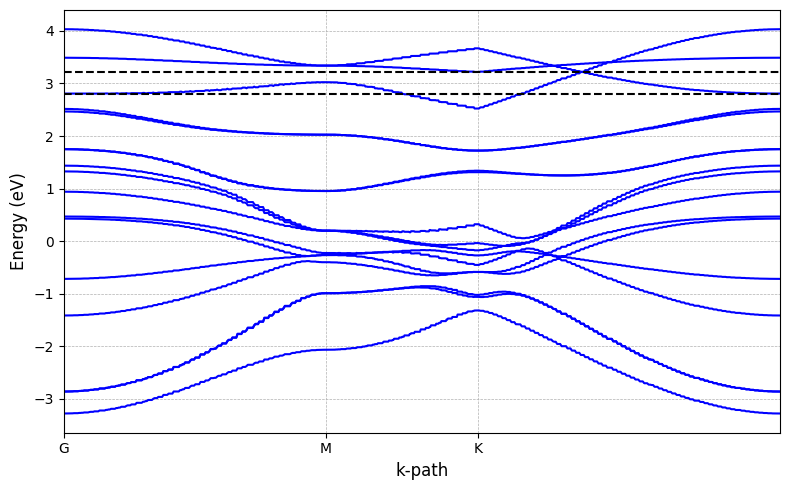


Running case for: U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


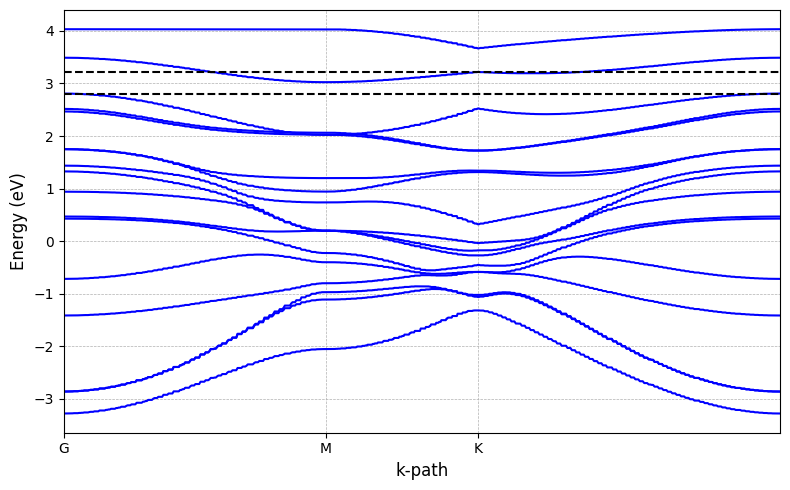

In [4]:
location = "bulk"
results = {}
for n, x in cases.items():
    print("")
    print(f"Running case for: U/t = {x[0]/-1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, -0.2, -1, x)
    problem.setup(
        N_r = 10,
        N_k = 200,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem
    g = problem.geometry
    tb_bulk = problem.hamiltonian[location]["tight_binding"]
    invariants = problem.hamiltonian[location]["topological_invariants"]
    bands = [i for i in range(7, 24)]
    dE, E0, E1 = invariants.get_band_gap(22, 21, only_dE=False)
    tb_bulk.plot_band_structure(g, bands, energies=[E0, E1]) # bands = [21, 22]
       

In [5]:
g = results[2].geometry
tb_bulk = results[2].hamiltonian[location]["tight_binding"]
invariants = results[2].hamiltonian[location]["topological_invariants"]

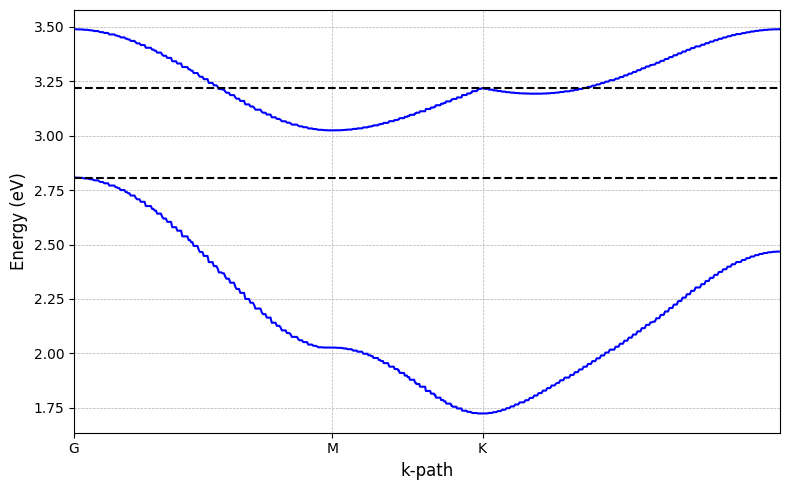

In [6]:
tb_bulk.plot_band_structure(g, bands = [21, 22], energies=[E0, E1]) 

In [9]:
Z_2 = invariants.Z2_invariant(bands= [23, 22], print_deltas=True)
print(f"Z2 = {Z_2}")

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 = 1


Calculating non-Abelian Chern Invariant...
Non-Abelian Chern Invariant - Done!
-3.9999999999999982


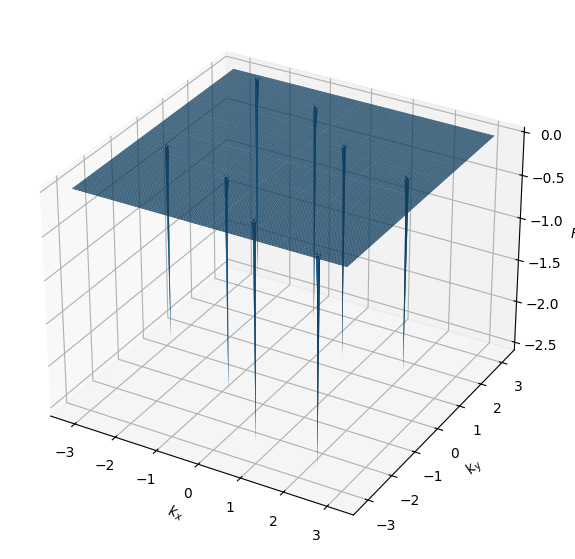

In [8]:
C, F = invariants.non_abelian_chern_invariant(bands=[22, 23])
print(C)
invariants.plot_berry_flux(F)